<a href="https://colab.research.google.com/github/MinThuKhant763/machine-learning/blob/main/Scikit_Learn_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from sklearn.datasets import load_diabetes
dataset = load_diabetes(as_frame=True,scaled=False)
data_df = dataset.data
print("The input dataset is : \n")
print(data_df.head())
print(data_df.tail())

input_feature = dataset.feature_names
print(input_feature)
print(dataset.DESCR)

The input dataset is : 

    age  sex   bmi     bp     s1     s2    s3   s4      s5    s6
0  59.0  2.0  32.1  101.0  157.0   93.2  38.0  4.0  4.8598  87.0
1  48.0  1.0  21.6   87.0  183.0  103.2  70.0  3.0  3.8918  69.0
2  72.0  2.0  30.5   93.0  156.0   93.6  41.0  4.0  4.6728  85.0
3  24.0  1.0  25.3   84.0  198.0  131.4  40.0  5.0  4.8903  89.0
4  50.0  1.0  23.0  101.0  192.0  125.4  52.0  4.0  4.2905  80.0
      age  sex   bmi      bp     s1     s2    s3    s4      s5     s6
437  60.0  2.0  28.2  112.00  185.0  113.8  42.0  4.00  4.9836   93.0
438  47.0  2.0  24.9   75.00  225.0  166.0  42.0  5.00  4.4427  102.0
439  60.0  2.0  24.9   99.67  162.0  106.6  43.0  3.77  4.1271   95.0
440  36.0  1.0  30.0   95.00  201.0  125.2  42.0  4.79  5.1299   85.0
441  36.0  1.0  19.6   71.00  250.0  133.2  97.0  3.00  4.5951   92.0
['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass

In [3]:
disease_progression = dataset.target
print("The output feature values are : \n")
print(disease_progression)

The output feature values are : 

0      151.0
1       75.0
2      141.0
3      206.0
4      135.0
       ...  
437    178.0
438    104.0
439    132.0
440    220.0
441     57.0
Name: target, Length: 442, dtype: float64


Text(0, 0.5, 'Diabetes Progression')

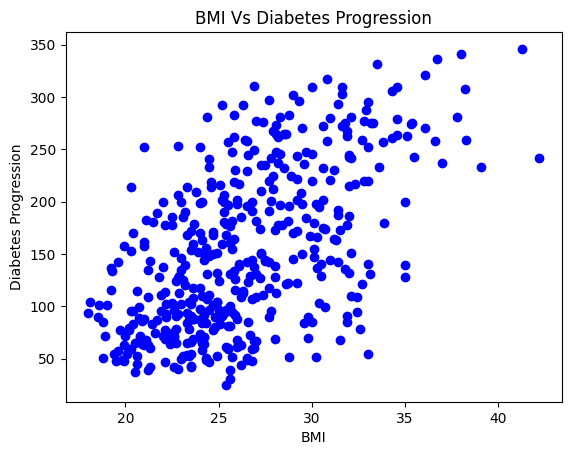

In [4]:
import matplotlib.pyplot as plt
plt.scatter(data_df["bmi"],disease_progression,color="blue")
plt.title("BMI Vs Diabetes Progression")
plt.xlabel("BMI")
plt.ylabel("Diabetes Progression")

In [6]:
X = data_df[["bmi"]]
y = disease_progression
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=0)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler = scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)
X_train[0:3,:]



array([[ 0.06364526],
       [-1.56789685],
       [-0.70803006]])

In [9]:
from sklearn.linear_model import LinearRegression
untrain_model = LinearRegression()
trained_model = untrain_model.fit(X_train,y_train)
intercept = trained_model.intercept_
coefficient = trained_model.coef_
print("The intercept is ",intercept)
print("The coefficient is ",coefficient)

The intercept is  151.60623229461754
The coefficient is  [47.98832087]


In [10]:
y_pred = trained_model.predict(X_test)
print("The predicted values are ",y_pred)

The predicted values are  [255.17426905 211.79462571 161.0087018  129.26749936 196.98206457
 247.76798848 123.97729895 174.76322286 205.44638522 198.04010465
  95.41021675 198.04010465 115.5129783  107.04865765 239.30366783
 130.32553944  94.35217667 101.75845724  70.01725479 191.69186416
 180.05342327 163.12478196 128.20945928 209.67854555 206.5044253
 169.47302245 111.28081797 108.10669773 156.77654147 177.9373431
 149.3702609  100.70041716 141.96398033 140.90594025 146.19614066
 172.6471427  136.67377993 143.02202042 153.60242123 185.34362367
  88.00393618 141.96398033 145.13810058 148.31222082 182.16950343
  92.23609651 133.49965968 176.87930302 119.74513862 185.34362367
 130.32553944 105.99061756 170.53106253 144.0800605  194.86598441
 134.55769976 182.16950343 148.31222082 147.25418074 164.18282204
 192.74990424 175.82126294 201.2142249  131.38357952 211.79462571
 180.05342327  91.17805642 199.09814473 193.80794433  80.59765561
 127.15141919 127.15141919 122.91925887 188.51774392

In [11]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
mse = mean_squared_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)
print("Mean Squared Error : %.2f" %mse)
print("R2 score : %.2f" %r2)

Mean Squared Error : 4150.68
R2 score : 0.19


In [12]:
new_bmi_values = [[20],[22],[25],[27],[30]]
scaled_values = scaler.transform(new_bmi_values)
print("New BMI Values",new_bmi_values)
print("Scaled Values",scaled_values)



New BMI Values [[20], [22], [25], [27], [30]]
Scaled Values [[-1.39151392]
 [-0.95055659]
 [-0.2891206 ]
 [ 0.15183672]
 [ 0.81327271]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [16]:
prediction = trained_model.predict(scaled_values)
print(prediction)

[ 84.82981594 105.99061756 137.73182001 158.89262164 190.63382408]
